In [2]:
import pandas as pd
import numpy as np

# Load station summary

In [3]:
df = pd.read_parquet("../data/processed/station_summary.parquet")
print(df.shape)
print(df.head())



(2160, 14)
   start_station_id  total_trips  casual_trips  member_trips  casual_share  \
0           2009.04          221           124            97      0.561086   
1           2158.08          197            56           141      0.284264   
2           2190.08          195            71           124      0.364103   
3           2231.10          155            68            87      0.438710   
4           2240.06          170            83            87      0.488235   

   avg_duration_casual  avg_duration_member  avg_distance_casual  \
0          2190.059194          1280.789794             1.260496   
1          1188.031786           831.328362             1.315942   
2          1471.565577          1297.978427             2.855367   
3          1098.562206           899.890874             2.046109   
4          1366.095120           914.267575             1.550043   

   avg_distance_member  weekend_trip_share  peak_hour  start_lat  start_lng  \
0             2.356308          

# Build spatial weights matrix

In [13]:
#using k-nearest neighbors to build spatial weights matrix
from libpysal.weights import KNN

coords = df[['start_lng', 'start_lat']].values
coords[:5]

array([[-74.03513,  40.6115 ],
       [-74.03091,  40.61689],
       [-74.02744,  40.61717],
       [-74.03261,  40.61946],
       [-74.0402 ,  40.61919]])

In [15]:
print(df.columns.tolist())

['start_station_id', 'total_trips', 'casual_trips', 'member_trips', 'casual_share', 'avg_duration_casual', 'avg_duration_member', 'avg_distance_casual', 'avg_distance_member', 'weekend_trip_share', 'peak_hour', 'start_lat', 'start_lng', 'start_station_name']


In [16]:
k = 8  # each station's 8 nearest neighbors — a common default, adjust if needed
w = KNN.from_array(coords, k=k)
print(f"Number of observations: {w.n}")
print(f"Neighbors per station: {k}")

Number of observations: 2160
Neighbors per station: 8


In [19]:
# quick sanity check: look at the neighbors of one station
sample_id = 0  # index position, not station_id
print(f"Station: {df.iloc[sample_id]['start_station_name']}")
print(f"Neighbor indices: {w.neighbors[sample_id]}")
print(df.iloc[w.neighbors[sample_id]][['start_station_name', 'start_lat', 'start_lng']])

Station: Shore Rd & 4 Ave
Neighbor indices: [np.int64(1), np.int64(3), np.int64(4), np.int64(2), np.int64(8), np.int64(5), np.int64(6), np.int64(10)]
            start_station_name  start_lat  start_lng
1                4 Ave & 94 St   40.61689  -74.03091
3                3 Ave & 92 St   40.61946  -74.03261
4         Shore Rd & Oliver St   40.61919  -74.04020
2   Fort Hamilton Pkwy & 92 St   40.61717  -74.02744
8                89 St & 3 Ave   40.62137  -74.03209
5                5 Ave & 88 St   40.62021  -74.02717
6                4 Ave & 87 St   40.62184  -74.02863
10          86 St & Ridge Blvd   40.62402  -74.03396


In [ ]:
w.transform = 'r' # transform weights to row-standardized form

# Test for spatial autocorrelation

In [23]:
#check whether casual_share is spatially clustered at all.
from esda.moran import Moran

y = df['casual_share'].values
moran = Moran(y, w)

In [24]:
print(f"Moran's I: {moran.I: .4f}")
print(f"Expected I under randomness: {moran.EI: .4f}")
print(f"p-value (simulated): {moran.p_sim: .4f}")

Moran's I:  0.4954
Expected I under randomness: -0.0005
p-value (simulated):  0.0010


In [25]:
# quick interpretation check
if moran.p_sim < 0.05:
    print("Statistically significant spatial clustering detected.")
else:
    print("No statistically significant spatial clustering detected.")

Statistically significant spatial clustering detected.


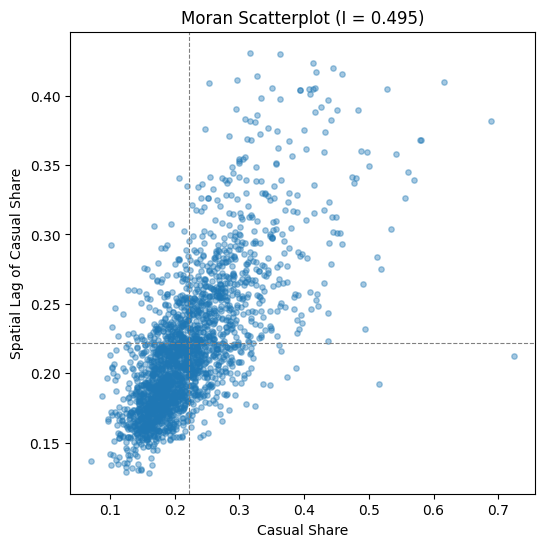

In [26]:
import matplotlib.pyplot as plt

lag_casual_share = w.sparse @ y  # spatially lagged values (average of each station's neighbors)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y, lag_casual_share, alpha=0.4, s=15)
ax.axhline(y.mean(), color='gray', linestyle='--', linewidth=0.8)
ax.axvline(y.mean(), color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Casual Share')
ax.set_ylabel('Spatial Lag of Casual Share')
ax.set_title(f"Moran Scatterplot (I = {moran.I:.3f})")
plt.show()